# First iteration of generating metric ablation plots with example panels,
showing two possible variants of organizing ablation results (by analysis type vs by ablation type) 

In [1]:
library(magick)
library(ggplot2)
library(cowplot)

Linking to ImageMagick 7.1.1.2
Enabled features: cairo, fontconfig, freetype, fftw, rsvg, webp, x11
Disabled features: ghostscript, heic, lcms, pango, raw

Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”
Warning message:
“package ‘cowplot’ was built under R version 4.2.3”


In [2]:
# --------------------------
# Helper: read first page of PDF, trim it
# --------------------------
read_pdf_trim <- function(file, density = 400) {
  img <- magick::image_read_pdf(file, density = density)[1]
  magick::image_trim(img)
}


# --------------------------
# Helper: convert image to a cowplot canvas
# x/y/width/height let you tune inner padding if needed
# --------------------------
pdf_to_panel <- function(file, density = 400,
                         x = 0.02, y = 0.02,
                         width = 0.96, height = 0.96) {
  img <- read_pdf_trim(file, density = density)
  cowplot::ggdraw() +
    cowplot::draw_image(img, x = x, y = y, width = width, height = height)
}


# --------------------------
# Helper: make one row = metric panel + example panel
# metric panel narrower, example panel wider
# --------------------------
make_pair_row <- function(metric_file, eg_file,
                          metric_rel_width = 2,
                          gap_rel_width = 0.3,
                          eg_rel_width = 5,
                          density = 400) {

  metric_plot <- pdf_to_panel(metric_file, density = density)
  eg_plot     <- pdf_to_panel(eg_file, density = density)

  spacer <- cowplot::ggdraw()  # empty plot = gap

  cowplot::plot_grid(
    metric_plot,
    spacer,
    eg_plot,
    nrow = 1,
    rel_widths = c(metric_rel_width, gap_rel_width, eg_rel_width),
    align = "h",
    axis = "tb"
  )
}


# --------------------------
# Helper: blank panel occupying one row
# --------------------------
blank_panel <- function() {
  cowplot::ggdraw()
}

# --------------------------
# Helper: add per-panel letter labels
# --------------------------
labeled_panel <- function(panel, label,
                          label_x = 0.01,
                          label_y = 0.99,
                          label_size = 14) {
  cowplot::ggdraw(panel) +
    cowplot::draw_label(
      label,
      x = label_x, y = label_y,
      hjust = 0, vjust = 1,
      fontface = "bold",
      size = label_size
    )
}

## Variant 1: Group by regression analysis, show all ablation plots on the left column and example panels on the right

In [3]:
save_figure_dir <- "./plots/figures/"
if (!dir.exists(save_figure_dir)) {
    dir.create(save_figure_dir, recursive = TRUE)
}

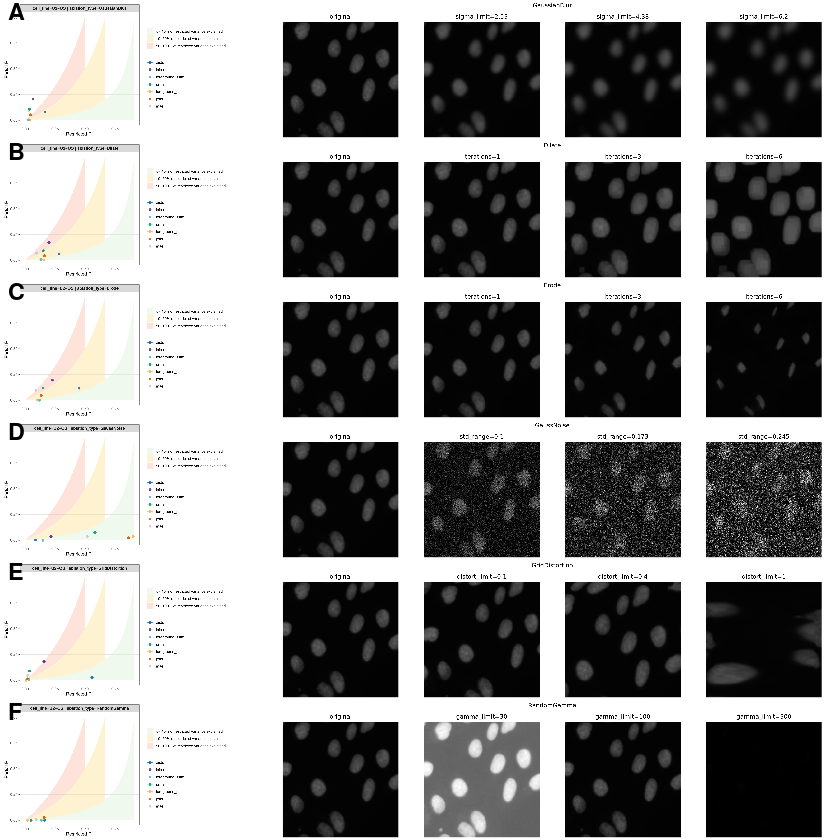

In [4]:
# --------------------------
# Input files
# --------------------------
blur_metric_panel_file <- "./plots/fig_panels/plate1_u2os_nest_confluence_GaussianBlur.pdf"
blur_eg_panel_file     <- "./plots/fig_panels/GaussianBlur_sigma_limit_U2OS_density=4000_seed=1.pdf"

dilate_metric_panel_file <- "./plots/fig_panels/plate1_u2os_nest_confluence_Dilate.pdf"
dilate_eg_panel_file     <- "./plots/fig_panels/Dilate_iterations_U2OS_density=4000_seed=1.pdf"

erode_metric_panel_file <- "./plots/fig_panels/plate1_u2os_nest_confluence_Erode.pdf"
erode_eg_panel_file     <- "./plots/fig_panels/Erode_iterations_U2OS_density=4000_seed=1.pdf"

noise_metric_panel_file <- "./plots/fig_panels/plate1_u2os_nest_confluence_GaussNoise.pdf"
noise_eg_panel_file     <- "./plots/fig_panels/GaussNoise_std_range_U2OS_density=4000_seed=1.pdf"

distort_metric_panel_file <- "./plots/fig_panels/plate1_u2os_nest_confluence_GridDistortion.pdf"
distort_eg_panel_file     <- "./plots/fig_panels/GridDistortion_distort_limit_U2OS_density=4000_seed=1.pdf"

gamma_metric_panel_file <- "./plots/fig_panels/plate1_u2os_nest_confluence_RandomGamma.pdf"
gamma_eg_panel_file     <- "./plots/fig_panels/RandomGamma_gamma_limit_U2OS_density=4000_seed=1.pdf"


# --------------------------
# Build the six rows
# --------------------------
row_blur <- make_pair_row(
  blur_metric_panel_file,
  blur_eg_panel_file
)

row_dilate <- make_pair_row(
  dilate_metric_panel_file,
  dilate_eg_panel_file
)

row_erode <- make_pair_row(
  erode_metric_panel_file,
  erode_eg_panel_file
)

row_noise <- make_pair_row(
  noise_metric_panel_file,
  noise_eg_panel_file
)

row_distort <- make_pair_row(
  distort_metric_panel_file,
  distort_eg_panel_file
)

row_gamma <- make_pair_row(
  gamma_metric_panel_file,
  gamma_eg_panel_file
)

# --------------------------
# Stack rows vertically
# equal row height
# --------------------------
final_fig <- cowplot::plot_grid(
  row_blur,
  row_dilate,
  row_erode,
  row_noise,
  row_distort,
  row_gamma,
  ncol = 1,
  rel_heights = rep(1, 6),
  labels = c("A", "B", "C", "D", "E", "F"),
  label_size = 14,
  label_fontface = "bold",
  label_x = 0.01,
  label_y = 0.98,
  hjust = 0,
  vjust = 1,
  align = "v",
  axis = "lr"
)

final_fig

In [5]:
ggsave(
  paste0(save_figure_dir, "combined_ablation_panels.pdf"),
  final_fig,
  width = 16,
  height = 24,
  device = cairo_pdf,
  bg = "white"
)

## Variant 2: Group by ablation type, show all analysis types on the left column and example panels across seeding densities on the right

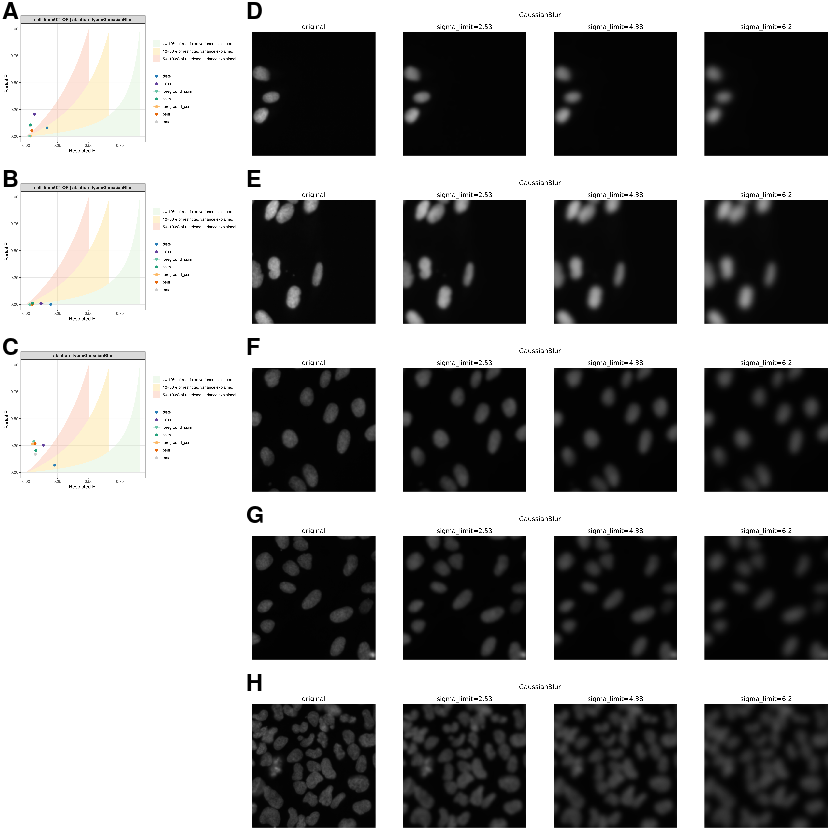

In [6]:
# --------------------------
# Panels
# --------------------------
blur_nest_confluence_metric_panel_file <- "./plots/fig_panels/plate1_u2os_nest_confluence_GaussianBlur.pdf"
blur_nest_plate_metric_panel_file      <- "./plots/fig_panels/u2os_conf8000_nest_plate_GaussianBlur.pdf"
blur_nest_cell_metric_panel_file       <- "./plots/fig_panels/all_conf8000_nest_cell_GaussianBlur.pdf"

blur_density1000_eg_panel_file  <- "./plots/fig_panels/GaussianBlur_sigma_limit_U2OS_density=1000_seed=1.pdf"
blur_density2000_eg_panel_file  <- "./plots/fig_panels/GaussianBlur_sigma_limit_U2OS_density=2000_seed=1.pdf"
blur_density4000_eg_panel_file  <- "./plots/fig_panels/GaussianBlur_sigma_limit_U2OS_density=4000_seed=1.pdf"
blur_density8000_eg_panel_file  <- "./plots/fig_panels/GaussianBlur_sigma_limit_U2OS_density=8000_seed=1.pdf"
blur_density12000_eg_panel_file <- "./plots/fig_panels/GaussianBlur_sigma_limit_U2OS_density=12000_seed=1.pdf"


# --------------------------
# Build left-column analysis panels
# --------------------------
panel_A <- labeled_panel(
  pdf_to_panel(blur_nest_confluence_metric_panel_file),
  "A"
)

panel_B <- labeled_panel(
  pdf_to_panel(blur_nest_plate_metric_panel_file),
  "B"
)

panel_C <- labeled_panel(
  pdf_to_panel(blur_nest_cell_metric_panel_file),
  "C"
)

# Two blank rows to align with 5-row right column
panel_blank_1 <- blank_panel()
panel_blank_2 <- blank_panel()

left_column <- cowplot::plot_grid(
  panel_A,
  panel_B,
  panel_C,
  panel_blank_1,
  panel_blank_2,
  ncol = 1,
  rel_heights = rep(1, 5),
  align = "v",
  axis = "lr"
)

# --------------------------
# Build right-column example panels
# --------------------------
panel_D <- labeled_panel(
  pdf_to_panel(blur_density1000_eg_panel_file),
  "D"
)

panel_E <- labeled_panel(
  pdf_to_panel(blur_density2000_eg_panel_file),
  "E"
)

panel_F <- labeled_panel(
  pdf_to_panel(blur_density4000_eg_panel_file),
  "F"
)

panel_G <- labeled_panel(
  pdf_to_panel(blur_density8000_eg_panel_file),
  "G"
)

panel_H <- labeled_panel(
  pdf_to_panel(blur_density12000_eg_panel_file),
  "H"
)

right_column <- cowplot::plot_grid(
  panel_D,
  panel_E,
  panel_F,
  panel_G,
  panel_H,
  ncol = 1,
  rel_heights = rep(1, 5),
  align = "v",
  axis = "lr"
)

# --------------------------
# Combine columns
# left = 3 metric rows + 2 blank rows
# right = 5 example rows
# --------------------------
final_fig <- cowplot::plot_grid(
  left_column,
  right_column,
  nrow = 1,
  rel_widths = c(2, 5),   # tune this if needed
  align = "h",
  axis = "tb"
)

final_fig

In [7]:
ggsave(
  paste0(save_figure_dir, "blur_ablation_analysis_and_eg.pdf"),
  final_fig,
  width = 16,
  height = 24,
  device = cairo_pdf,
  bg = "white"
)